In [23]:
!pip install tensorflow_datasets

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout,BatchNormalization
from tensorflow.keras.models import Sequential
import os
import tensorflow_datasets as tfds
import tensorflow as tf

**Data Set Information**

In [25]:
dataset, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)

In [26]:
class_names = info.features['label'].names
class_names

['cat', 'dog']

In [27]:
#creating a directory
for i, example in enumerate(dataset['train']):
  # example = (image, label)
  image, label = example
  save_dir = './cats_vs_dogs/train/{}'.format(class_names[label])
  os.makedirs(save_dir, exist_ok=True)

  filename = save_dir + "/" + "{}_{}.jpg".format(class_names[label], i)
  tf.keras.preprocessing.image.save_img(filename, image.numpy())
  # print(filename)
  # break

array([[[19, 29, 59],
        [21, 31, 61],
        [20, 31, 63],
        ...,
        [28, 43, 82],
        [32, 45, 89],
        [23, 36, 80]],

       [[ 3, 12, 45],
        [11, 22, 54],
        [21, 32, 64],
        ...,
        [29, 41, 81],
        [37, 49, 91],
        [32, 44, 86]],

       [[ 8, 18, 52],
        [ 7, 19, 53],
        [14, 26, 60],
        ...,
        [ 9, 21, 57],
        [20, 31, 69],
        [18, 28, 68]],

       ...,

       [[14, 18, 43],
        [10, 14, 39],
        [ 9, 13, 37],
        ...,
        [22, 24, 35],
        [20, 22, 33],
        [10, 12, 23]],

       [[24, 28, 53],
        [20, 24, 49],
        [21, 25, 49],
        ...,
        [24, 26, 37],
        [23, 25, 36],
        [13, 15, 26]],

       [[ 8, 12, 37],
        [14, 18, 43],
        [25, 29, 53],
        ...,
        [33, 35, 46],
        [33, 35, 46],
        [19, 21, 32]]], dtype=uint8)
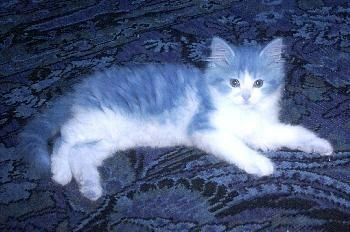

In [30]:
import cv2
cat = cv2.imread('/content/cats_vs_dogs/train/cat/cat_10026.jpg')
cat

array([[[ 83, 125,  70],
        [ 84, 126,  71],
        [ 84, 126,  71],
        ...,
        [ 34,  55,  40],
        [ 27,  48,  33],
        [ 28,  49,  34]],

       [[ 82, 124,  69],
        [ 84, 126,  71],
        [ 85, 127,  72],
        ...,
        [ 20,  41,  26],
        [ 14,  35,  20],
        [ 16,  37,  22]],

       [[ 75, 118,  61],
        [ 78, 121,  64],
        [ 81, 124,  67],
        ...,
        [ 13,  35,  17],
        [  9,  31,  13],
        [ 11,  33,  15]],

       ...,

       [[ 19,  45,  22],
        [ 12,  38,  15],
        [ 16,  42,  19],
        ...,
        [125, 134, 108],
        [122, 128, 103],
        [122, 131, 105]],

       [[ 18,  44,  21],
        [ 14,  40,  17],
        [ 25,  51,  28],
        ...,
        [ 83,  92,  71],
        [ 74,  81,  60],
        [ 73,  82,  61]],

       [[ 24,  50,  27],
        [ 29,  55,  32],
        [ 43,  69,  46],
        ...,
        [ 51,  62,  42],
        [ 40,  49,  29],
        [ 40,  51,  31]]], dtype=uint8)
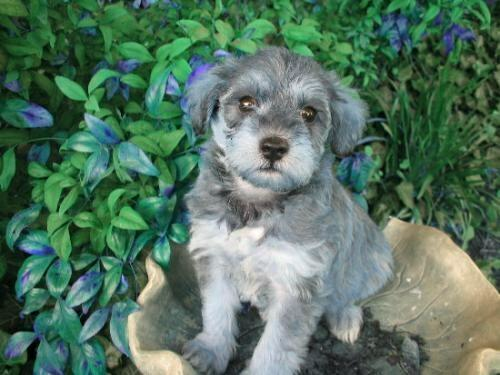

In [34]:
dog = cv2.imread('/content/cats_vs_dogs/train/dog/dog_10020.jpg')
dog

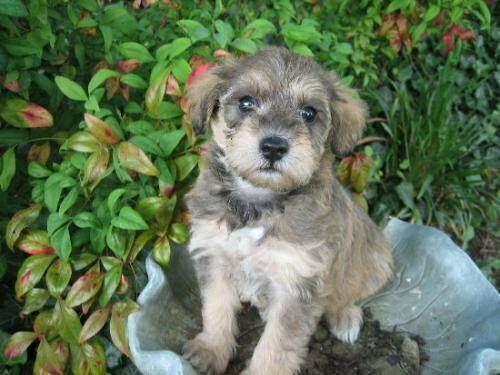

In [35]:
from google.colab.patches import cv2_imshow
cv2_imshow(dog)

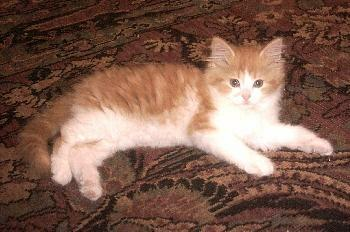

In [36]:
from google.colab.patches import cv2_imshow
cv2_imshow(cat)

In [37]:
#set up the ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2,rotation_range=10,
                             width_shift_range=0.1,height_shift_range=0.1,
                             shear_range=0.1,zoom_range=0.1,horizontal_flip=True)

In [38]:
datagen

In [39]:
train_generator = datagen.flow_from_directory('/content/cats_vs_dogs/train',target_size=(150,150),batch_size=32,
                                              class_mode='binary',subset='training')

Found 18611 images belonging to 2 classes.


In [40]:
validation_generator = datagen.flow_from_directory('/content/cats_vs_dogs/train',target_size = (150,150),batch_size=32,
                                                   class_mode='binary',subset='validation')

Found 4651 images belonging to 2 classes.


**Training-Epoch means training the machine with images and later testing with a untrained data**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Model definition
model = Sequential()
model.add(Conv2D(32, kernel_size=3, activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Conv2D(64, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Conv2D(128, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# Model compilation
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping and training
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
training_history = model.fit(train_generator, epochs=10, validation_data=validation_generator, callbacks=[early_stop])
print(training_history.history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
471/582 ━━━━━━━━━━━━━━━━━━━━ 28s 254ms/step - accuracy: 0.5877 - loss: 4.6746

In [ ]:
#save model
model.save('cats_vs_dogs.keras')

In [ ]:
model_load=tf.keras.models.load_model('cats_vs_dogs.keras')

In [ ]:
import requests
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image

# 🔹 Provide a direct image URL
img_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRoBuMvSuYezLE9rwI-zOJeIOmcIGfDPqOvFA&s"

# 🔹 Load and resize image
img = Image.open(requests.get(img_url, stream=True).raw).convert("RGB").resize((150, 150))

# 🔹 Convert to array
img_array = image.img_to_array(img)

# 🔹 Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# 🔹 Normalize (FIXED: normalize img_array, not img)
img_array = img_array / 255.0

# 🔹 Predict (FIXED: use img_array)
prediction = model.predict(img_array)

# 🔹 Binary classification
TH = 0.5
prediction = int(prediction[0][0] > TH)

# 🔹 Class labels
Classes = {v: k for k, v in train_generator.class_indices.items()}

print(Classes[prediction])

In [ ]:
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image

# 🔹 Provide a direct image URL
img_url = "https://img.freepik.com/free-photo/portrait-beautiful-purebred-pussycat-with-shorthair-orange-collar-neck-sitting-floor-reacting-camera-flash-scared-looking-light-indoor_8353-12551.jpg?semt=ais_hybrid&w=740&q=80"

# 🔹 Load and resize image
img = Image.open(requests.get(img_url, stream=True).raw).convert("RGB").resize((150, 150))

# 🔹 Convert to array
img_array = image.img_to_array(img)

# 🔹 Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# 🔹 Normalize (FIXED: normalize img_array, not img)
img_array = img_array / 255.0

# 🔹 Predict (FIXED: use img_array)
prediction = model.predict(img_array)

# 🔹 Binary classification
TH = 0.5
prediction = int(prediction[0][0] > TH)

# 🔹 Class labels
Classes = {v: k for k, v in train_generator.class_indices.items()}

print(Classes[prediction])